In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut, cross_validate, train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import randint, uniform


# SCIKIT-LEARN

### 1. EXPLORATION ET PRÉPARATION

- Charger les données et afficher info/describe

In [2]:
df_telecom = pd.read_csv('../data/03_DONNEES.csv')

df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  InternetCharges   7043 non-null   float64


In [3]:
df_telecom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,InternetCharges,MonthlyCharges,TotalCharges,Churn
0,customer_1,Male,0,No,Yes,51,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,0.00,43.53,2220.03,No
1,customer_2,Male,1,Yes,Yes,14,Yes,Yes,DSL,No internet service,No internet service,Yes,No internet service,Yes,No internet service,Two year,46.00,109.39,1531.46,No
2,customer_3,Female,0,Yes,No,71,No,No,DSL,Yes,No,Yes,Yes,No,Yes,One year,34.36,99.36,7054.56,No
3,customer_4,Male,1,Yes,No,60,Yes,No phone service,Fiber optic,No internet service,No internet service,No,No internet service,Yes,No internet service,Two year,65.56,115.12,6907.20,No
4,customer_5,Male,0,Yes,No,20,No,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0.00,20.00,400.00,Yes


In [4]:
df_telecom.describe()

,SeniorCitizen,tenure,InternetCharges,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.503337,35.902598,46.783412,91.006110,3279.987099
std,0.500024,20.945973,43.812203,54.001753,2976.418208
min,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,18.000000,0.000000,39.310000,940.000000
50%,1.000000,36.000000,40.670000,91.350000,2284.460000
75%,1.000000,54.000000,80.625000,132.930000,5022.900000
max,1.000000,72.000000,139.930000,238.040000,15151.680000


In [5]:
df_telecom.shape

(7043, 20)

- Analyser la distribution de Churn

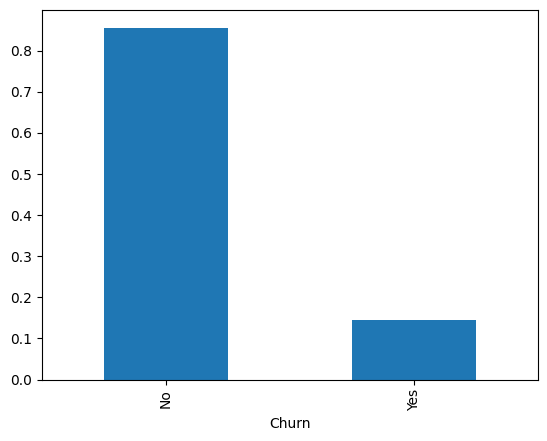

In [6]:
df_telecom['Churn'].value_counts(normalize=True).plot(kind='bar')
plt.show()

- Identifier et traiter les valeurs manquantes

In [7]:
missing_count = df_telecom.isnull().sum()
missing_percent = (missing_count / len(df_telecom)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent})
missing_df = missing_df.sort_values(by='Missing Percent', ascending=False)

missing_df

,Missing Count,Missing Percent
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


- Encoder les variables catégorielles (One-hot encoding)

##### Détection des features à garder

In [8]:
# features à garder
features_to_keep = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "InternetCharges",
    "MonthlyCharges",
    "TotalCharges"
]
target = "Churn"

X = df_telecom[features_to_keep].copy()
y = df_telecom[target].copy()

# feature numériques et catégorielles
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.to_list()
categorical_features = X.select_dtypes(include=["object"]).columns.to_list()

print(f"numériques: {numeric_features}")
print("====")
print(f"categoricielle: {categorical_features}")

numériques: ['SeniorCitizen', 'tenure', 'InternetCharges', 'MonthlyCharges', 'TotalCharges']
====
categoricielle: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']


In [9]:
# Encoder les variables catégorielles (One-hot encoding)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

- Normaliser les variables numériques (StandardScaler)

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [11]:
# prepare le pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### 2. MODÉLISATION

In [12]:
# split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [13]:
# entrainement des modèles Logistic Regression - Random Forest - Gradient Boosting
model_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=100, class_weight="balanced"))
])

model_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42, n_estimators=100))
])

model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"))
])

In [14]:
# calcul des statistiques
models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "Gradient Boosting": model_gb
}
results = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    y_pred = model.predict(X_test)
    
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label="Yes"),
        "recall": recall_score(y_test, y_pred, pos_label="Yes"),
        "f1": f1_score(y_test, y_pred, pos_label="Yes"),
        "time": elapsed_time
    }
    
    print(name)
    print("Accuracy:", results[name]["accuracy"])
    print("Precision:", results[name]["precision"])
    print("Recall:", results[name]["recall"])
    print("F1:", results[name]["f1"])
    print("time", elapsed_time)
    print()
    


Logistic Regression
Accuracy: 0.6313298627543776
Precision: 0.23094170403587444
Recall: 0.6889632107023411
F1: 0.3459277917716205
time 0.03824019432067871

Random Forest
Accuracy: 0.8566019876952201
Precision: 0.4090909090909091
Recall: 0.030100334448160536
F1: 0.056074766355140186
time 0.3824276924133301

Gradient Boosting
Accuracy: 0.8547089446284903
Precision: 0.25
Recall: 0.013377926421404682
F1: 0.025396825396825397
time 0.6725196838378906



In [15]:
# Sauvegarde en JSON
try:
    with open("../data/model_metrics_sklearn_comparaison.json", "w") as f:
        json.dump(results, f, indent=4)
    print("Results saved to 'model_metrics_sklearn.json'")
except Exception as e:
    print("Error saving results:", e)

Results saved to 'model_metrics_sklearn.json'


In [16]:
best_model = max(results.items(), key=lambda x: x[1]["recall"])[0]

print("Meilleur modèle :", best_model)
print("Score recall :", results[best_model]["recall"])

Meilleur modèle : Logistic Regression
Score recall : 0.6889632107023411


### 3. ÉVALUATION ET INTERPRÉTATION

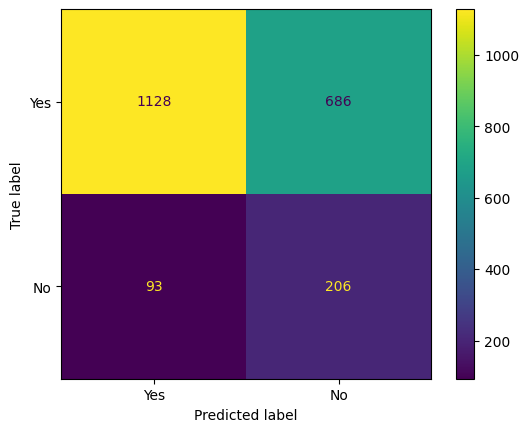

In [17]:
# selection et entrainement du meilleur modèle
best_model_obj = models[best_model]
y_pred_best = best_model_obj.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Yes","No"])
disp.plot()

In [18]:
# sauvegarde des predictions
y_test_pred = best_model_obj.predict(X_test)
y_test_proba = best_model_obj.predict_proba(X_test)[:, 1]

df_predictions = X_test.copy()
df_predictions["Churn_pred"] = y_test_pred
df_predictions["Churn_proba"] = y_test_proba

df_predictions.to_csv("../data/predictions_test.csv", index=False)
print("Fichier predictions_test.csv créé ")

Fichier predictions_test.csv créé 


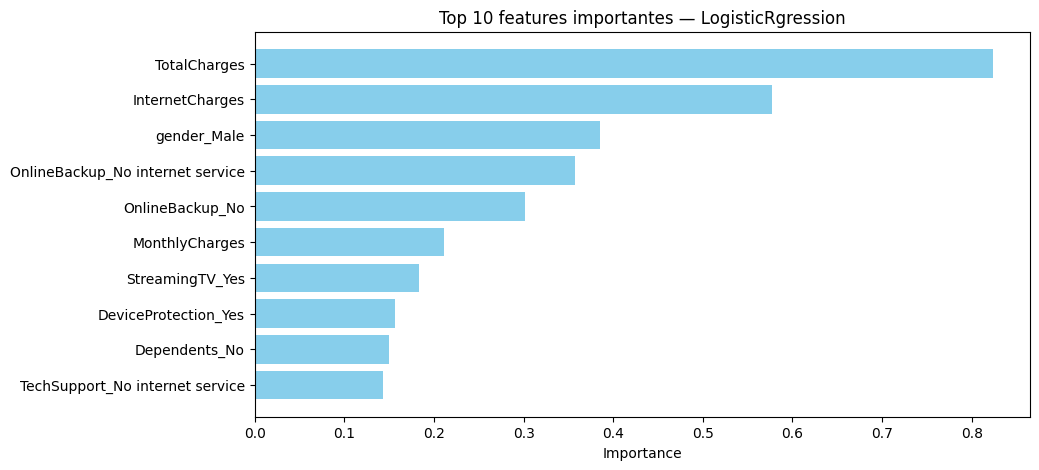

In [19]:
# Extraire et visualiser les 10 features les plus importantes
rf_clf = best_model_obj.named_steps["classifier"]
preprocessor_fit = best_model_obj.named_steps["preprocessor"]

# noms des variables
ohe = preprocessor_fit.named_transformers_["cat"].named_steps["onehot"]
cat_features = ohe.get_feature_names_out(categorical_features).tolist()
all_features = cat_features + numeric_features

# importance
importances = np.abs(rf_clf.coef_[0])
indices = np.argsort(importances)[::-1]

# Top 10 features
top_n = 10
top_indices = indices[:top_n]
top_names = [all_features[i] for i in top_indices]
top_importances = importances[top_indices]

# visualisation
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(top_n), top_importances[::-1], color="skyblue")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_n} features importantes — LogisticRgression")
plt.show()

In [20]:
# Sauvegarde CSV
df_importances = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

df_importances.to_csv("../data/feature_importance.csv", index=False)
print("Fichier feature_importance.csv créé")

Fichier feature_importance.csv créé


In [21]:
#- Cross-validation (5-fold)

# Stratified 5-fold car classe non équilibrée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

start_time = time.time()
cv_results = cross_validate(
    rf_clf, X_train, y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)
elapsed_time = time.time() - start_time

# Récupérer le nom du modèle depuis le pipeline
model_name = rf_clf.named_steps['classifier'].__class__.__name__

# Stocker les métriques avec le nom dynamique
metrics = {
    model_name: {
        "accuracy": cv_results['test_accuracy'].mean(),
        "precision": cv_results['test_precision'].mean(),
        "recall": cv_results['test_recall'].mean(),
        "f1": cv_results['test_f1'].mean(),
        "time": elapsed_time
    }
}

print(f"Test accuracy: {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Test F1: {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"Test precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"Test recall: {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")

print(f"Train accuracy: {cv_results['train_accuracy'].mean():.4f} ± {cv_results['train_accuracy'].std():.4f}")
print(f"Fit time: {cv_results['fit_time'].mean():.4f} ± {cv_results['fit_time'].std():.4f}")


Test accuracy: 0.8554 ± 0.0015
Test F1: 0.4652 ± 0.0059
Test precision: 0.6278 ± 0.2454
Test recall: 0.5019 ± 0.0030
Train accuracy: 0.8554 ± 0.0002
Fit time: 0.0240 ± 0.0017


c:\Users\Administrateur\Desktop\ecf-3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [22]:
# sauvegarde en json
try:
    with open("../data/model_metrics_sklearn_best_model_.json", "w") as f:
        json.dump(metrics, f, indent=4)
except Exception as e:
    print("Erreur :", e)

In [23]:
param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],  # l1 possible si solver compatible
    "classifier__solver": ["lbfgs"],
    "classifier__class_weight": [None, "balanced"]
}

nb_combi = 1

for values in param_grid.values():
    nb_combi *= len(values)
    
print(f"nombre de combinaison de paramètres: {nb_combi}")



nombre de combinaison de paramètres: 12


In [24]:
grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=skf,        
    scoring="f1_macro",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

c:\Users\Administrateur\Desktop\ecf-3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.001, 0.01, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [25]:
# résultat
print(f"Meilleur paramètrs: {grid_search.best_params_}")
print(f"Meilleur score cv: {grid_search.best_score_}")

Meilleur paramètrs: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Meilleur score cv: 0.5445390216421607


### 4. RECOMMANDATIONS MÉTIER

- Identifier les 20 clients avec probabilité churn > 80% et analyse de leur profils


In [26]:
# 1️Récupérer le meilleur modèle avec les meilleurs paramètres
best_model_obj = grid_search.best_estimator_
proba_churn = best_model_obj.predict_proba(X)[:, 1]  # colonne "Yes"

df_clients = X.copy()
df_clients["churn_proba"] = proba_churn

top_clients = df_clients[df_clients["churn_proba"] > 0.8].sort_values(by="churn_proba", ascending=False).head(20)

profile_cols = ["Contract", "InternetService", "tenure", "MonthlyCharges", "churn_proba"]
top_clients_profile = top_clients[profile_cols]

top_clients_profile

,Contract,InternetService,tenure,MonthlyCharges,churn_proba
2180,Month-to-month,Fiber optic,3,103.98,0.829539
6668,Month-to-month,Fiber optic,1,128.19,0.826673
4489,Month-to-month,Fiber optic,3,153.33,0.819628
3355,Month-to-month,Fiber optic,6,135.53,0.817256
1883,Month-to-month,Fiber optic,15,143.42,0.812593
6658,Month-to-month,Fiber optic,2,147.17,0.812002
1775,Month-to-month,Fiber optic,0,150.50,0.810105
2091,Month-to-month,DSL,4,96.55,0.809129
4914,Month-to-month,Fiber optic,0,127.12,0.808651
5306,Month-to-month,DSL,5,86.63,0.804260


- Proposer 3 actions de rétention

- **Offre promotionnelle** ciblée : Une bonne partie des personnnes avec un taux de churn élevé sont au **début de l'engagement ou vers la fin**.

- Programme d'**engagement** pour éviter la perte des personnes vers la **fin** de leur **abonnement** (par exemple un mois offert).

- Un appel quelques jours après l"ouverture du service pour **communiquer** des éventuels problèmes avec le **client** et le **retenir**


- Estimer ROI (coût action vs économie)

In [27]:
# cout de l'action
cost_action_per_client = 20

# estimation suivant la moyenne des clients
avg_revenue_monthly = top_clients_profile["MonthlyCharges"].mean()
avg_tenure_retention = 3 

# Estimation économie
roi_per_client = (avg_revenue_monthly * avg_tenure_retention) - cost_action_per_client

total_roi = roi_per_client * len(top_clients_profile)

print(f"ROI par client estimé: €{roi_per_client:.2f}")
print(f"ROI total pour 20 clients: €{total_roi:.2f}")

ROI par client estimé: €376.79
ROI total pour 20 clients: €6028.72
